In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os

print(os.listdir('/kaggle/input'))

['datasets']


In [3]:
dataset = os.listdir('/kaggle/input')[0]
print(dataset)
print(os.listdir(f'/kaggle/input/{dataset}'))

datasets
['awsaf49']


In [5]:
import os

print(os.listdir('/kaggle/input/datasets/awsaf49'))

['mnist-dataset']


In [6]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    if "mnist_png" in root:
        print(root)
        break

/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png


In [10]:
train_path = "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training"
test_path = "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/testing"

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist

In [17]:
(x_train, _), (x_test, _) = mnist.load_data()

Exception: URL fetch failure on https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz: None -- [Errno -3] Temporary failure in name resolution

In [18]:
import os

train_path = "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training"

print(os.path.exists(train_path))

True


In [19]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels=None,
    color_mode="grayscale",
    image_size=(28, 28),
    batch_size=128,
    shuffle=False
)

Found 60000 files.


2026-07-12 06:02:39.299851: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [20]:
import numpy as np

x_train = np.concatenate([batch.numpy() for batch in train_ds], axis=0)

print(x_train.shape)

(60000, 28, 28, 1)


In [21]:
x_train = x_train.astype("float32") / 255.0

print(x_train.min())
print(x_train.max())

0.0
1.0


In [22]:
# Loading testing dataset
test_path = "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/testing"

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels=None,
    color_mode="grayscale",
    image_size=(28, 28),
    batch_size=128,
    shuffle=False
)

Found 10000 files.


In [23]:
x_test = np.concatenate([batch.numpy() for batch in test_ds], axis=0)

print(x_test.shape)

(10000, 28, 28, 1)


In [25]:
x_test = x_test.astype("float32") / 255.0

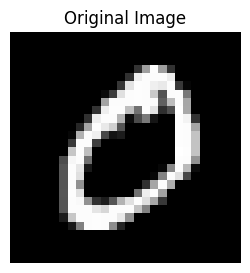

In [26]:
# Displying original image
import matplotlib.pyplot as plt

plt.figure(figsize=(3,3))
plt.imshow(x_train[0].squeeze(), cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

In [27]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

In [28]:
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

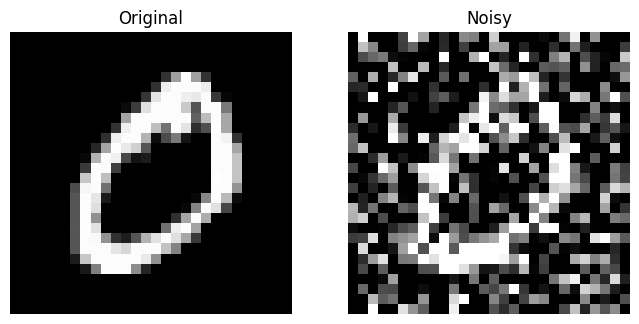

In [29]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(x_train[0].squeeze(), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(x_train_noisy[0].squeeze(), cmap="gray")
plt.title("Noisy")
plt.axis("off")

plt.show()

In [30]:
# Autoencoder building
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
input_img = Input(shape=(28, 28, 1))

#Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

#Decoder
x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)
autoencoder = Model(input_img, decoded)

In [31]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# compiling model
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [33]:
# model training
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 58s 120ms/step - accuracy: 0.8060 - loss: 0.1793 - val_accuracy: 0.8069 - val_loss: 0.0113
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 117ms/step - accuracy: 0.8105 - loss: 0.1175 - val_accuracy: 0.8066 - val_loss: 0.0161
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 116ms/step - accuracy: 0.8114 - loss: 0.1119 - val_accuracy: 0.8068 - val_loss: 0.0131
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 117ms/step - accuracy: 0.8119 - loss: 0.1090 - val_accuracy: 0.8066 - val_loss: 0.0132
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 116ms/step - accuracy: 0.8121 - loss: 0.1072 - val_accuracy: 0.8068 - val_loss: 0.0110
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 114ms/step - accuracy: 0.8123 - loss: 0.1059 - val_accuracy: 0.8063 - val_loss: 0.0144
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 114ms/step - accuracy: 0.8124 - loss: 0.1049 - val_accuracy: 0.8064 - val_loss: 0.0149
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 114ms/step - accuracy: 0.8125 - loss: 0

In [34]:
# convert noisy image into clean image
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


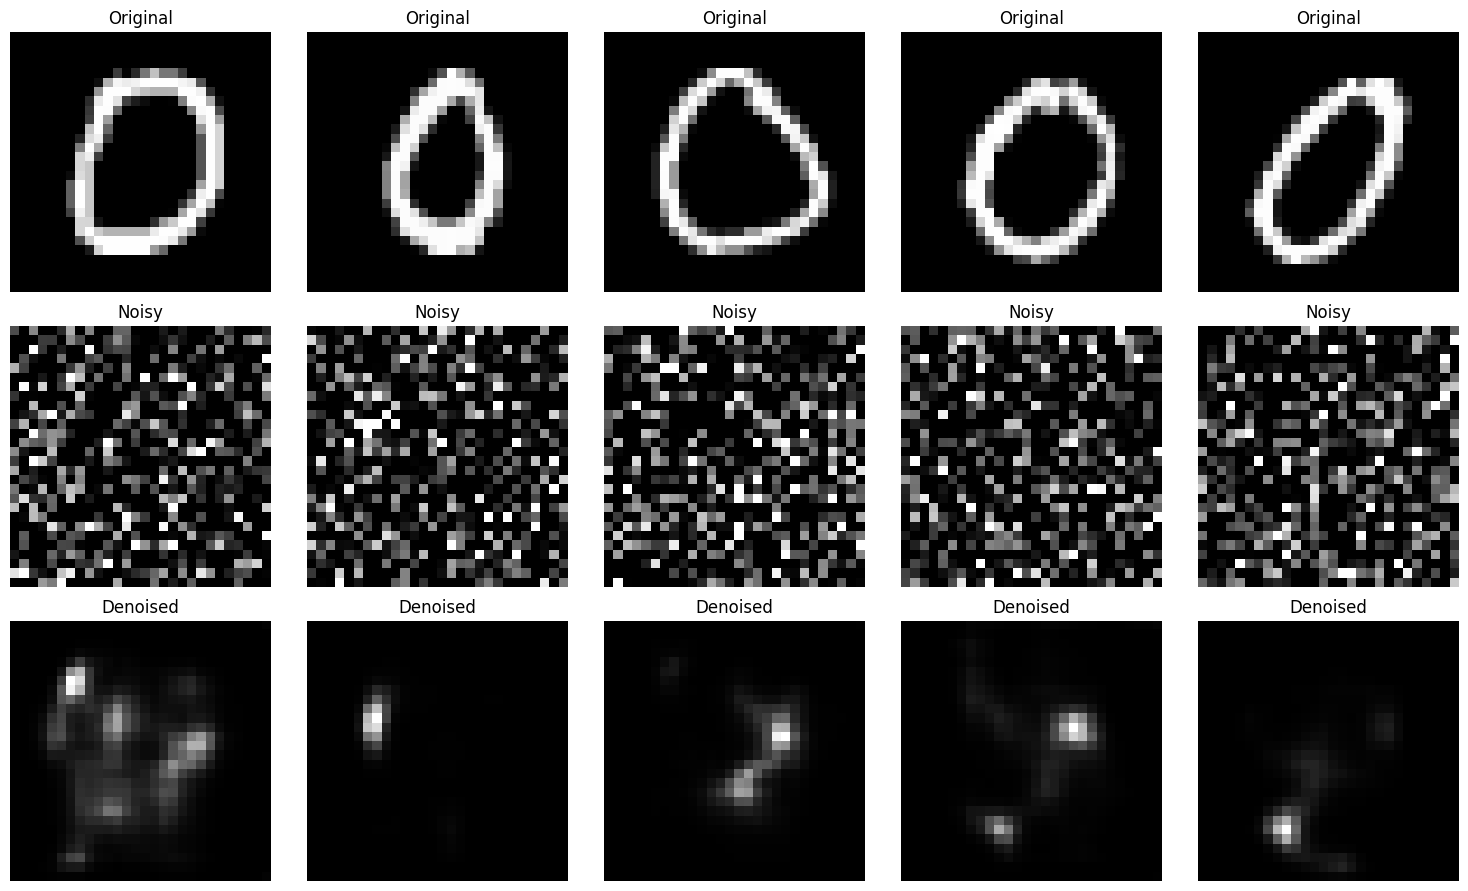

In [35]:
# Result
import matplotlib.pyplot as plt

n = 5

plt.figure(figsize=(15, 9))

for i in range(n):

    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3, n, i + n + 1)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3, n, i + 2*n + 1)
    plt.imshow(decoded_imgs[i].squeeze(), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Result
The Autoencoder model was successfully trained on the MNIST dataset to remove noise from handwritten digit images. 
The model learned to reconstruct clean images from noisy inputs. 
The denoised output images were visually similar to the original images, demonstrating that the autoencoder effectively performed image denoising.